In [38]:
import matplotlib.pyplot as plt
import seaborn as sbs
import numpy as np
import pandas as pd
import polars as pl
import matplotlib as mpl
import iohinspector
plt.style.use("default")
mpl.rcdefaults()


DIM = 5

In [2]:
dt_bbob = pd.read_csv("aocc_processed_BBOB.csv")
max_aocc_per_function = dt_bbob.loc[dt_bbob.groupby('function_id')['AOCC'].idxmax()]


dm = iohinspector.DataManager()
dm.add_folder("irace_data")
data_load = dm.load(include_meta_data=True)

x_values = iohinspector.get_sequence(1, 50_000, 50, True, True)
data_load = data_load.with_columns([
    pl.when(pl.col("algorithm_name") == "Default")
      .then(0)
      .otherwise(
          pl.col("algorithm_name")
            .str.extract(r"elite-(\d+)", 1)
            .cast(pl.Int64)
            .fill_null(0)
      )
      .alias("elite_number")
])

data_load = data_load.with_columns([
    pl.when(pl.col("algorithm_name") == "Default")
      .then(pl.lit("Default"))
      .when(pl.col("algorithm_name").str.contains("NoLR"))
      .then(pl.lit("Without LR"))
      .otherwise(pl.lit("With LR"))
      .alias("lr_status")
])

In [ ]:
df_eaf = iohinspector.metrics.transform_fval(data_load, 1e-8, 1e2)
res = iohinspector.metrics.get_aocc(
    df_eaf, DIM * 10_000, free_vars=['algorithm_name', 'function_id'],
    return_as_pandas=False
)

In [299]:
df_pivot = res.pivot(values='AOCC', index='algorithm_name', on='function_id')
df_pivot = df_pivot.sort(by="algorithm_name")
axis_names = list(df_pivot['algorithm_name'])
df_pivot = df_pivot.drop("algorithm_name")
df_pivot = df_pivot.select(map(str, range(1, 25)))


# df_pivot
with_lr = [i for i, name in enumerate(axis_names) if '-LR' in name]
without_lr = [i for i, name in enumerate(axis_names) if '-NoLR' in name]
df = pl.concat([
    df_pivot[0],
    # df_pivot[with_lr].max(),
    df_pivot[without_lr].max()]
).to_pandas()
# df.index = ['Default', 'Tuned +LR', 'Tuned -LR']
df.index = ['Default', 'Tuned']
df['all'] = df.mean(axis=1)
df

,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,all
Default,0.993632,0.967332,0.141932,0.106262,0.998867,0.982227,0.471435,0.938335,0.939555,0.966431,...,0.291403,0.490551,0.332509,0.234002,0.182631,0.292384,0.216958,0.254561,0.106082,0.577696
Tuned,0.998485,0.993215,0.814173,0.406409,0.999682,0.988540,0.992749,0.984362,0.989174,0.987363,...,0.968002,0.971653,0.944344,0.739227,0.759524,0.925174,0.924059,0.895196,0.272150,0.891790


In [ ]:

algs_2009 = [
    "ALPS",           "DIRECT",        "LSstep",        "PSO",
    "AMALGAM",        "EDA-PSO",       "MA-LS-CHAIN",   "PSO-Bounds",
    "BAYEDA",         "FULLNEWUOA",    "MCS",           "RANDOMSEARCH",
    "BFGS",           "G3PCX",         "NELDER",        "Rosenbrock",
    "BIPOP-CMA-ES",   "GA",            "NELDERDOERR",   "VNS",
    "Cauchy-EDA",     "GLOBAL",        "NEWUOA",
    "CMA-ESPLUSSEL",  "iAMALGAM",      "ONEFIFTH",
    "DASA",           "IPOP-SEP-CMA-ES","POEMS",
    "DE-PSO",         "LSfminbnd",
]
dt_bbob = pd.read_csv("aoccdef_processed_BBOB.csv", index_col=0)

dt_bbob = dt_bbob[dt_bbob["alg"].isin(algs_2009)]
dt_bbob = dt_bbob[dt_bbob["dim"] == DIM]
dt_bbob = dt_bbob[dt_bbob["x"] == DIM * 10_000]
bbob_pivot = dt_bbob.pivot_table('aocc', 'alg', 'fid').reindex([x for x in range(1,25)], axis=1)


bbob2009 = bbob_pivot.max(axis=0)
bbob2009['all'] = bbob2009.mean()
bbob2009.index = df.columns

bbob_pivot['all'] = bbob_pivot.mean(axis=1)
bbob_pivot = bbob_pivot.sort_values("all", ascending=False)
bbob_pivot.columns = df.columns

df.loc['bbob2009'] = bbob2009
df_both = pd.concat([df, bbob_pivot])

df

,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,all
Default,0.993632,0.967332,0.141932,0.106262,0.998867,0.982227,0.471435,0.938335,0.939555,0.966431,...,0.291403,0.490551,0.332509,0.234002,0.182631,0.292384,0.216958,0.254561,0.106082,0.577696
Tuned,0.998485,0.993215,0.814173,0.406409,0.999682,0.988540,0.992749,0.984362,0.989174,0.987363,...,0.968002,0.971653,0.944344,0.739227,0.759524,0.925174,0.924059,0.895196,0.272150,0.891790
bbob2009,0.999727,0.998112,0.966872,0.961303,0.999801,0.983703,0.974474,0.992742,0.994724,0.984735,...,0.812206,0.913536,0.831549,0.372790,0.491168,0.963162,0.962999,0.619083,0.150380,0.856840
IPOP-SEP-CMA-ES,0.993928,0.979946,0.298173,0.130866,0.998635,0.974609,0.969144,0.952338,0.954796,0.935198,...,0.812206,0.913536,0.831549,0.296477,0.320995,0.742528,0.494408,0.485575,0.138555,0.735127
BIPOP-CMA-ES,0.992812,0.964259,0.201924,0.133517,0.998700,0.979275,0.974474,0.965469,0.964833,0.964014,...,0.768864,0.907544,0.812996,0.335615,0.250160,0.761289,0.676921,0.415226,0.137965,0.733480
AMALGAM,0.984548,0.968144,0.179258,0.119538,0.994296,0.934412,0.946672,0.939053,0.910896,0.967573,...,0.510863,0.726242,0.605803,0.298853,0.224880,0.618051,0.636813,0.619083,0.109218,0.684362
iAMALGAM,0.990300,0.976455,0.250234,0.118747,0.997804,0.965692,0.911648,0.943205,0.929958,0.973887,...,0.413404,0.631384,0.600569,0.272848,0.217262,0.609165,0.669125,0.551952,0.112086,0.675282
MA-LS-CHAIN,0.979875,0.939254,0.535284,0.229215,0.986522,0.934065,0.632777,0.923769,0.910652,0.891927,...,0.279796,0.683206,0.381592,0.278769,0.491168,0.802505,0.799651,0.507031,0.112737,0.674244
VNS,0.990449,0.954278,0.497877,0.252569,0.996953,0.975365,0.814423,0.869543,0.937429,0.955238,...,0.347089,0.499496,0.356193,0.251752,0.267464,0.831025,0.673692,0.241363,0.110482,0.657555
NELDERDOERR,0.997568,0.983038,0.232941,0.118783,0.999520,0.893690,0.439388,0.983119,0.988212,0.984735,...,0.337034,0.273133,0.237538,0.284682,0.207994,0.963162,0.962999,0.324766,0.150380,0.639868


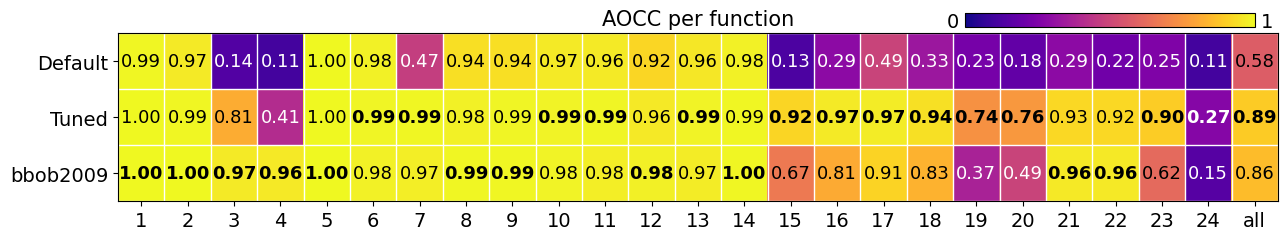

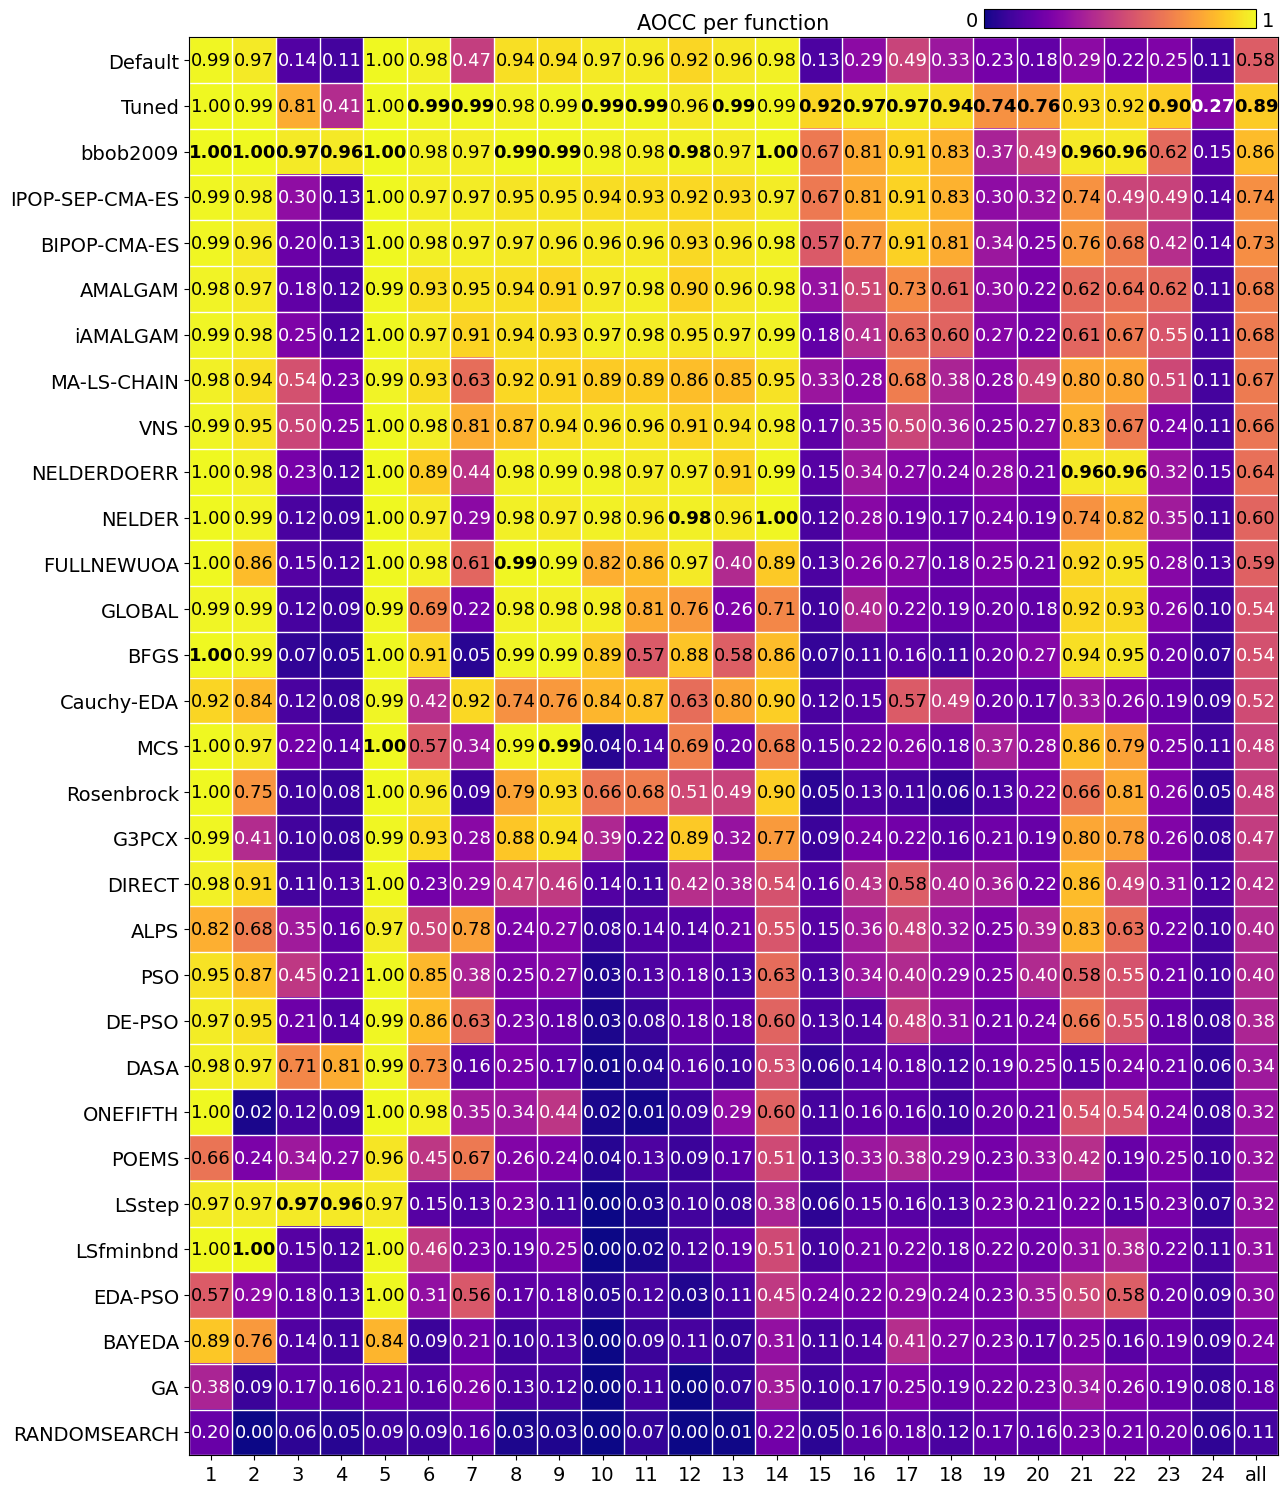

In [356]:
def plot_heatmap(
    df, 
    vmin=0,
    vmax=1, 
    cmap='plasma', 
    fmt = lambda value: f"{value:.2f}",
    fmtsize = 13,
    minimize = False,
):
    size = 15 if len(df) > 10  else 2.5
    fig, ax = plt.subplots(figsize=(13, size))
    im = ax.imshow(df.values, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)


    # labels
    ax.set_xticks(np.arange(df.shape[1]))
    ax.set_yticks(np.arange(df.shape[0]))
    ax.set_xticklabels(df.columns, fontsize=14)
    ax.set_yticklabels(df.index, fontsize=14)

    # annotate values
    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            colname = df.columns[j]
            value = df.iloc[i, j]
            weight = 'normal'
            if minimize and value == df[colname].min():
                weight = 'bold'
            elif not minimize and value == df[colname].max():
                weight = 'bold'
                
            r, g, b, _ = im.cmap(im.norm(value))
            brightness = 0.299 * r + 0.587 * g + 0.114 * b
            text_color = "white" if brightness < 0.5 and not np.isinf(value) else "black"
            ax.text(j, i, fmt(value), 
                    ha="center", va="center", 
                    color=text_color, 
                    fontdict=dict(size=fmtsize,weight=weight)
                )

    # grid lines
    ax.set_xticks(np.arange(-0.5, df.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, df.shape[0], 1), minor=True)
    ax.grid(which="minor", color="w", linestyle="-", linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)


    cax = ax.inset_axes([0.73, 1.0 + (0.05 * (2 / size)), 0.25 - (0.01  * np.log10(vmax)), 0.1 * (2 / size)])
    cbar = fig.colorbar(im, cax=cax, orientation="horizontal")

    cbar.set_ticks([])
    cbar.ax.text(-0.02, 0.4, f"{int(vmin)}", transform=cbar.ax.transAxes,
                ha="right", va="center", fontsize=14)
    cbar.ax.text(1.02, 0.4, f"{int(vmax)}", transform=cbar.ax.transAxes,
                ha="left", va="center", fontsize=14)

    ax.set_xticks(np.arange(-0.5, df.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, df.shape[0], 1), minor=True)
    ax.grid(which="minor", color="w", linestyle="-", linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)
    plt.tight_layout()
    return fig, ax    

fig, ax = plot_heatmap(df)
ax.set_title("AOCC per function", y=1., fontsize=15)
plt.savefig("aoc_per_func_small.pdf")

fig, ax = plot_heatmap(df_both)
ax.set_title("AOCC per function", y=1., fontsize=15)
plt.savefig("aoc_per_func_all.pdf")


In [366]:
data_load = data_load.with_columns([
    pl.when(pl.col("algorithm_name") == "Default")
      .then(0)
      .otherwise(
          pl.col("algorithm_name")
            .str.extract(r"elite-(\d+)", 1)
            .cast(pl.Int64)
            .fill_null(0)
      )
      .alias("elite_number")
])

data_load = data_load.with_columns([
    pl.when(pl.col("algorithm_name") == "Default")
      .then(pl.lit("Default"))
      .when(pl.col("algorithm_name").str.contains("NoLR"))
      .then(pl.lit("Without LR"))
      .otherwise(pl.lit("With LR"))
      .alias("lr_status")
])

data_aligned = iohinspector.align_data(data_load, 1e-8, group_cols=['data_id', 'function_id', 'algorithm_name', 'elite_number', 'lr_status'], x_col='raw_y', y_col='evaluations', maximization=False)        
dt_ert_irace = data_aligned.group_by(['raw_y', 'function_id', 'algorithm_name', 'elite_number', 'lr_status']).agg([
    (
            pl.col('evaluations').replace(np.inf, 50_000).sum()
            / pl.col('evaluations').is_finite().sum()
        ).alias("ERT")
    ])
dt_ert_irace = dt_ert_irace.to_pandas()


In [367]:
dt_ert_bbob = pd.read_csv("ERT_processed_BBOB.csv")
dt_ert_bbob = dt_ert_bbob[dt_ert_bbob["algorithm_name"].isin(algs_2009)]
bbob_ert_pivot = dt_ert_bbob.pivot_table('ERT', 'algorithm_name', 'function_id')
bbob_ert_pivot = bbob_ert_pivot.iloc[np.argsort(bbob_ert_pivot.replace(np.inf, 10_000_000 * DIM).mean(axis=1).values)]

In [388]:
df_ert = dt_ert_irace.pivot_table('ERT', 'algorithm_name', 'function_id')
df_ert = df_ert.sort_values("algorithm_name").reset_index()
axis_names = list(df_ert['algorithm_name'])
df_ert.index = df_ert['algorithm_name']
df_ert = df_ert.drop("algorithm_name", axis=1)

df_summary_ert = pd.DataFrame(index=['Default', 'Tuned'], columns=df_ert.columns)
# # Default row remains the same
df_summary_ert.loc['Default'] = df_ert.loc['Default']
# # Without LR row: select the best value for each column from elite-xNoLR rows
df_summary_ert.loc['Tuned'] = df_ert.filter(like='elite-', axis=0).filter(like='NoLR', axis=0).min(skipna=True)

df_ert = df_summary_ert.apply(pd.to_numeric, errors='coerce')
dt_both_ert = pd.concat([df_ert, bbob_ert_pivot])

df_ert.loc['bbob2009'] = bbob_ert_pivot.min(axis=0)

df_ert

function_id,1,2,3,4,5,6,7,8,9,10,...,15,16,17,18,19,20,21,22,23,24
Default,689.02,2082.960000,2.451290e+06,inf,61.24,1757.260000,89422.20,4177.937500,4052.040816,2137.900000,...,inf,1201307.5,2.451915e+06,inf,inf,inf,263036.750000,575848.000000,1.203671e+06,inf
Tuned,159.80,505.140000,1.292759e+04,8.657917e+04,16.96,2000.265306,461.46,1096.960000,859.820000,875.360000,...,5.792740e+03,2632.5,3.653300e+03,5.171240e+03,2.190293e+04,1.965913e+04,5649.875000,4812.840000,8.317959e+03,3.470509e+05
bbob2009,13.00,94.733333,1.657333e+03,1.146260e+04,10.00,1475.266667,1738.20,424.066667,372.800000,901.733333,...,2.168143e+04,12254.8,8.254933e+03,1.280293e+04,1.224008e+05,5.004907e+04,2123.466667,2249.133333,3.488720e+04,1.512396e+06


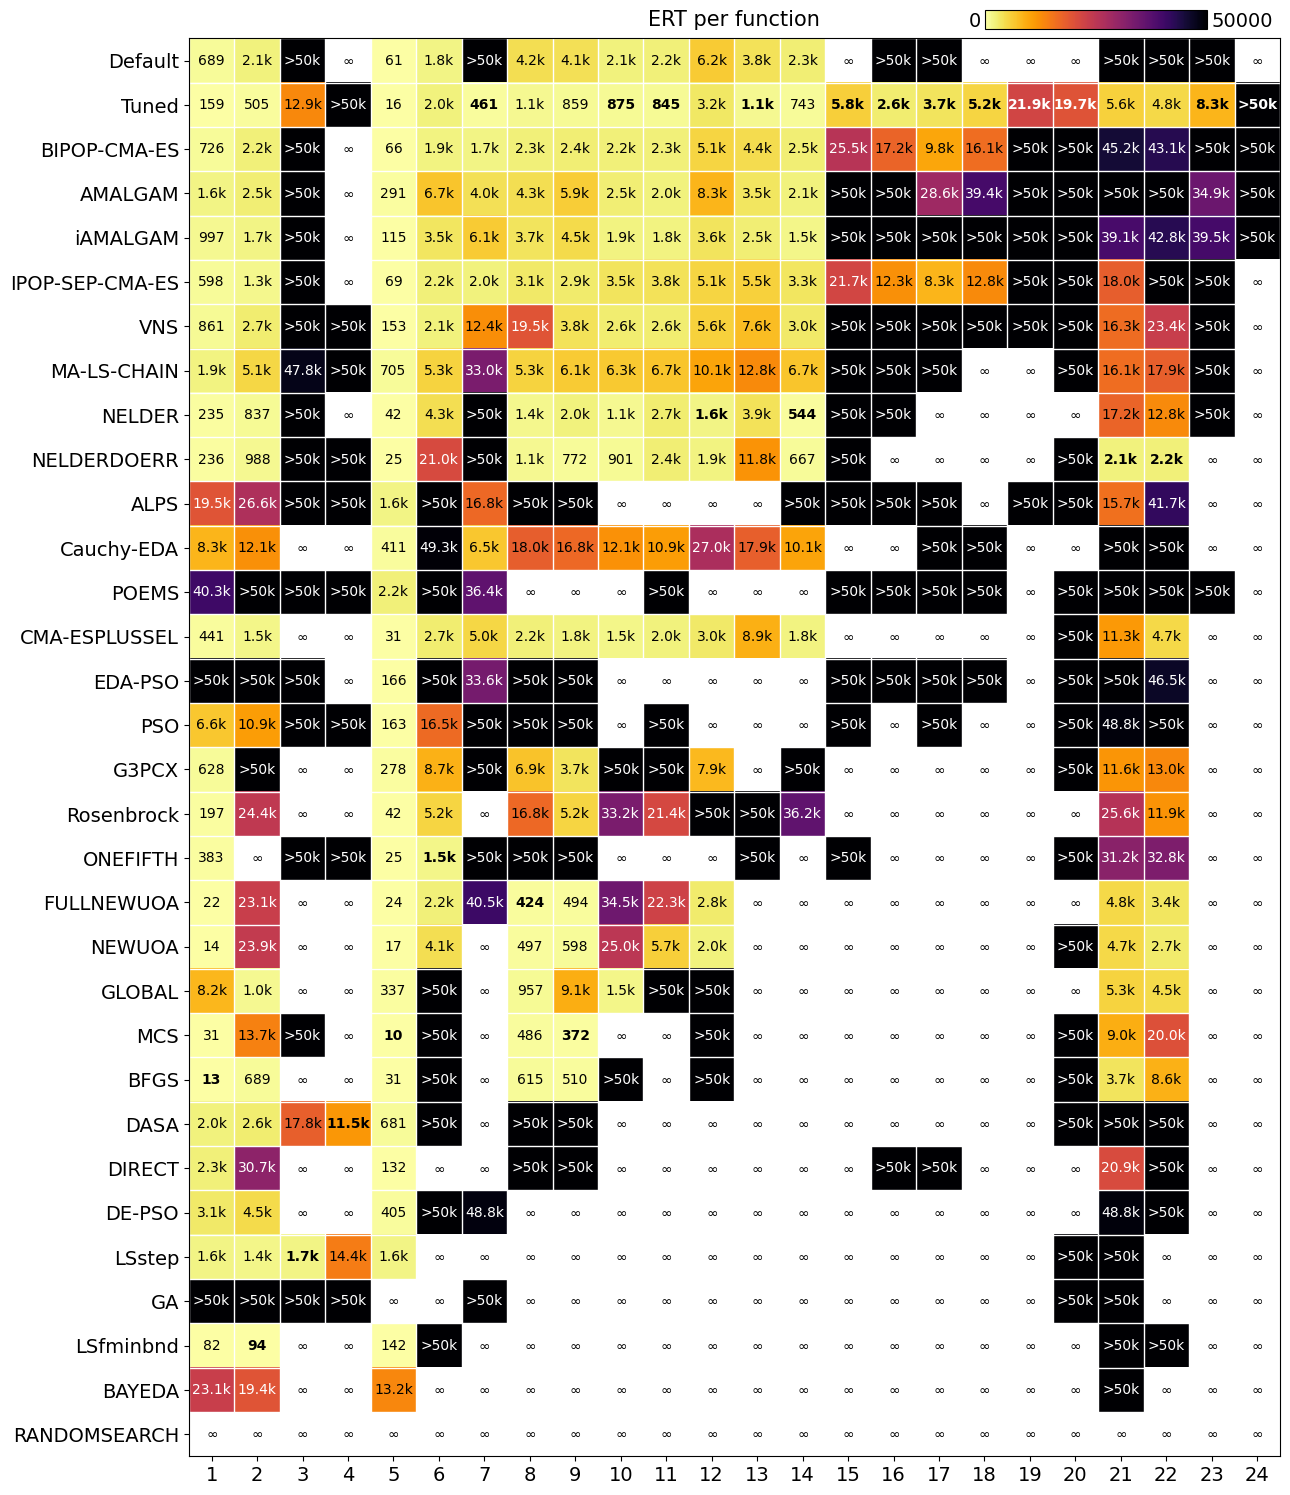

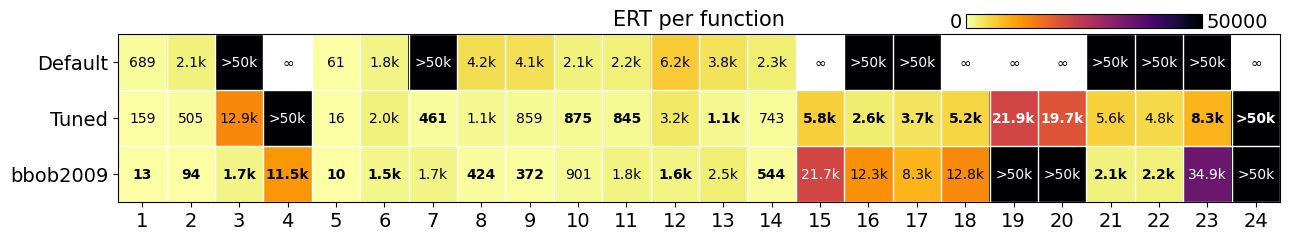

In [389]:
def fmt(value):
    if value == np.inf:
        return "$\\infty$"
    if value > 10_000 * DIM:
        return ">50k"
    if np.log10(value) > 3:
        return f"{value/1000:.1f}k"
    return f"{int(value):d}"

f, ax = plot_heatmap(dt_both_ert, fmt=fmt, vmax=10_000 * DIM, cmap='inferno_r', fmtsize=10, minimize=True)
ax.set_title("ERT per function", y=1.003, fontsize=15)
plt.savefig("ert_heatmap_all.pdf");

f, ax = plot_heatmap(df_ert, fmt=fmt, vmax=10_000 * DIM, cmap='inferno_r', fmtsize=10, minimize=True)
ax.set_title("ERT per function", y=1.003, fontsize=15)
plt.savefig("ert_heatmap_small.pdf");

In [413]:
modules = ['active', 'base_sampler', 'covariance', 'elitist', 'lambda_', 'local_restart',
       'mirrored', 'mu', 'orthogonal', 'sample_transform', 'sequential',
       'step_size_adaptation', 'threshold', 'weights_option']
modules_cat = modules.copy()
modules_cat.remove('lambda_')
modules_cat.remove('mu')

LR = 0
dts = []
for fid in range(1,25):
    temp = pd.read_csv(f"irace_SHAP_log/log_F{fid}D5LR{LR}_module_status_shap.csv")
    dts.append(temp)
dt_plot = pd.concat(dts).query(f'Module in {modules_cat}')

In [ ]:
from sklearn.preprocessing import LabelEncoder
shaps = pd.read_csv(f"SHAPS_irace/F{fid}D5LR{LR}.csv")
confs = pd.read_csv(f"irace_explogs_full/log_F{fid}D5LR{LR}_explog.csv")
merged_shap = confs.merge(shaps, left_index=True, right_index=True, suffixes=('', '_shap'))

categorical_columns = [
'active',
'base_sampler',
'covariance',
'elitist',
'local_restart',
'mirrored',
'orthogonal',
'sample_transform',
'sequential',
'step_size_adaptation',
'threshold',
'weights_option',
]

def get_str(v):
    if isinstance(v, str):
        if '1/2' in v:
            return "exponential"
        return v.replace("_", " ").lower()
    if isinstance(v, float) and np.isnan(v):
        return 'none'
    if isinstance(v, np.bool_):
        if v:
            return "on"
        return "off"
            


label_maps = {}
for col in categorical_columns:
    le = LabelEncoder()
    merged_shap[col] = le.fit_transform(merged_shap[col])
    label_maps[col] = {i: get_str(v) for i, v, in enumerate(le.classes_)}
label_maps

Processing F24 LR0


{'active': {0: 'off', 1: 'on'},
 'base_sampler': {0: 'gaussian', 1: 'halton', 2: 'sobol'},
 'covariance': {0: 'cholesky',
  1: 'cmsa',
  2: 'covariance',
  3: 'matrix',
  4: 'natural gradient',
  5: 'none',
  6: 'seperable'},
 'elitist': {0: 'off', 1: 'on'},
 'local_restart': {0: 'bipop', 1: 'ipop', 2: 'restart', 3: 'none'},
 'mirrored': {0: 'mirrored', 1: 'mirrored pairwise', 2: 'none'},
 'orthogonal': {0: 'off', 1: 'on'},
 'sample_transform': {0: 'cauchy', 1: 'gaussian', 2: 'uniform', 3: 'dweibull'},
 'sequential': {0: 'off', 1: 'on'},
 'step_size_adaptation': {0: 'csa',
  1: 'msr',
  2: 'mxnes',
  3: 'psr',
  4: 'sa',
  5: 'sr',
  6: 'tpa'},
 'threshold': {0: 'off', 1: 'on'},
 'weights_option': {0: 'exponential', 1: 'default', 2: 'equal'}}

In [ ]:
dt_plot[['Module', 'Status']].map(lambda x: label_maps[x][y])
# dt_plot['status'] = [f"{x} {label_maps[x][y]}" for x,y in zip(dt_plot['Module'], dt_plot['Status'])]
# dt_plot.drop(columns=['Module', 'Status'], inplace=True)
# dt_plot
# dt_heatmap = dt_plot.pivot_table(index='fid', columns='conf_status', values='SHAP Value', aggfunc='mean')
# plt.figure(figsize=(32, 12))
# sbs.heatmap(dt_heatmap, center=0, annot=True, fmt=".2f", cmap='RdBu', annot_kws={'size': 11})
# for x in [2, 5, 12, 14, 18, 21, 23, 27, 29, 36, 38]:
#     plt.axvline(x, color='black', linestyle='--', lw=2)
# plt.ylabel("Function ID")
# plt.xlabel("")
# plt.yticks(rotation=0, fontsize=14)

# plt.tight_layout()
# plt.savefig(f"Figures/Shap_heatmap_allfid_allmodules_LR{LR}.png", dpi=300)

TypeError: <lambda>() missing 1 required positional argument: 'y'

In [398]:
dt_plot

,Index,SHAP Value,fid,LR,conf_status
0,0,-0.017171,1,0,active True
1,1,-0.017171,1,0,active True
2,2,-0.017171,1,0,active True
3,3,-0.017171,1,0,active True
4,4,-0.017171,1,0,active True
...,...,...,...,...,...
1049967,74993,-0.006228,24,0,weights_option default
1049968,74994,-0.006228,24,0,weights_option default
1049969,74995,-0.006228,24,0,weights_option default
1049970,74996,-0.006228,24,0,weights_option default
